# Airline Passenger Satisfaction

## Problem Statement:
#### Approximately 56.5% of passengers report being Neutral or Dissatisfied with the airline. To address this issue, this analysis will examine both passenger, travel, service, and operational factor to provide managers with actionable insights for improvement.

## Research Objectives

1. **Understand** the demographic and travel characteristics of the airline's passengers.
2. **Identify** passenger groups with higher levels of dissatisfaction.
3. **Determine** which service areas are most strongly associated with overall passenger satisfaction.
4. **Examine** the lowest-rated service areas among dissatisfied passenger groups.
5. **Assess** whether flight delays are associated with passenger dissatisfaction..

## Exploratory Data Analysis (EDA)

## 1- Data Info:
#### Getting the data and exploring it (includes descriptive statistics)

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading the CSV files
df1 = pd.read_csv('test.csv')
df2 = pd.read_csv('train.csv')

In [6]:
# merging the test and train datasets
merged_df = pd.concat([df1, df2], ignore_index=True)

In [84]:
merged_df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [100]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [102]:
merged_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


## 2- Data Handling:
#### Cleaning, transforming, and combining data

In [712]:
#looking for missing values
merged_df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction    

In [714]:
#the percentage of the missing values
merged_df.isnull().mean()*100

Unnamed: 0                           0.000000
id                                   0.000000
Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Inflight wifi service                0.000000
Departure/Arrival time convenient    0.000000
Ease of Online booking               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Online boarding                      0.000000
Seat comfort                         0.000000
Inflight entertainment               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Inflight service                     0.000000
Cleanliness                       

In [127]:
merged_df.duplicated().sum()

0

In [131]:
merged_df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction    

In [10]:
# categorizing the age groups to use it later in the analysis
merged_df["Age Groups"]= pd.cut(merged_df["Age"],[7,18,35,55,86], labels=["Youth", "Young Adult","Adult", "Older Adult"])
merged_df['Age Groups'].value_counts()

Age Groups
Adult          56856
Young Adult    40675
Older Adult    21279
Youth          10385
Name: count, dtype: int64

## 3- The Analysis

### 3.1- What is the problem?

In [12]:
merged_df["satisfaction"].value_counts(normalize=True)* 100

satisfaction
neutral or dissatisfied    56.553742
satisfied                  43.446258
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Overall Satisfaction')

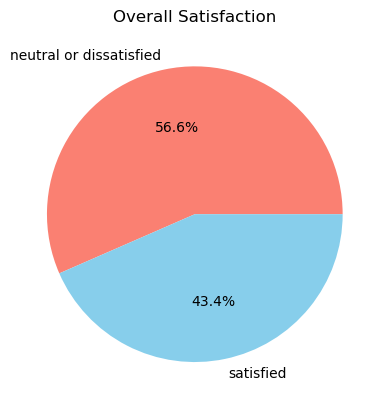

In [14]:
merged_df['satisfaction'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=["salmon","skyblue"])
plt.ylabel('')
plt.title('Overall Satisfaction')

### 3.2- Profiling

<Axes: ylabel='count'>

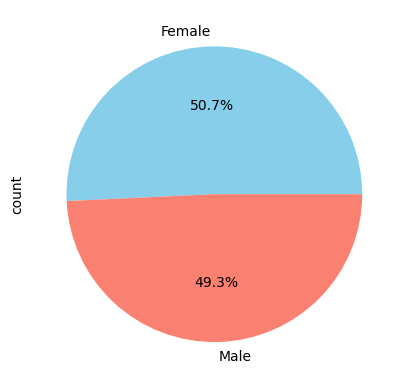

In [16]:
merged_df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['skyblue', 'salmon'])

<Axes: ylabel='count'>

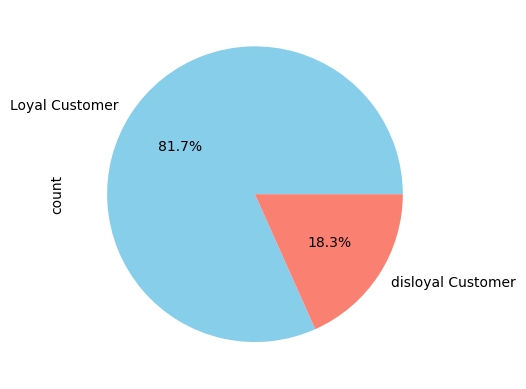

In [18]:
merged_df['Customer Type'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['skyblue', 'salmon'])

<Axes: xlabel='Class'>

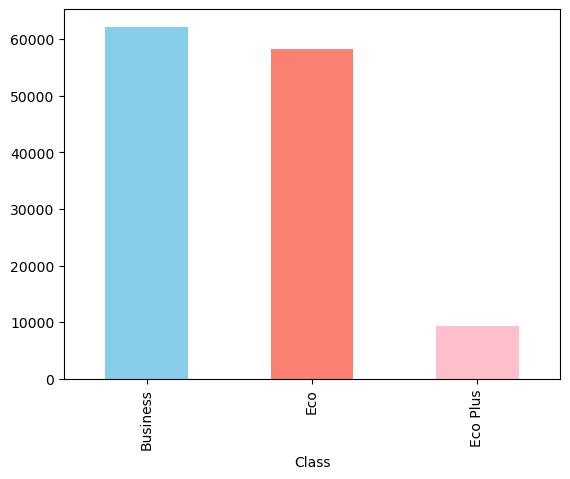

In [20]:
merged_df['Class'].value_counts().plot(kind='bar',color=['skyblue', 'salmon', 'pink'])

Text(0.5, 1.0, 'Passenger Distribution by Age Group')

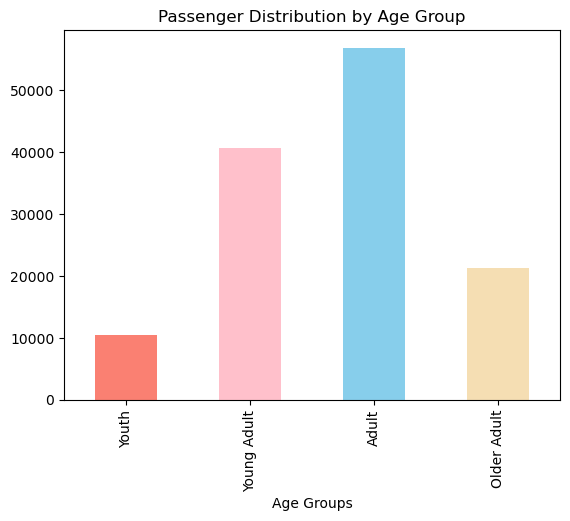

In [24]:
age_counts = merged_df['Age Groups'].value_counts().sort_index()
age_counts.plot(kind='bar',color=['salmon', 'pink', 'skyblue','wheat'])
plt.ylabel('')
plt.title('Passenger Distribution by Age Group')

### 3.3- Who is Dissatisfied?

#### 3.3.1 By Travel Class

(array([0, 1, 2]),
 [Text(0, 0, 'Business'), Text(1, 0, 'Eco'), Text(2, 0, 'Eco Plus')])

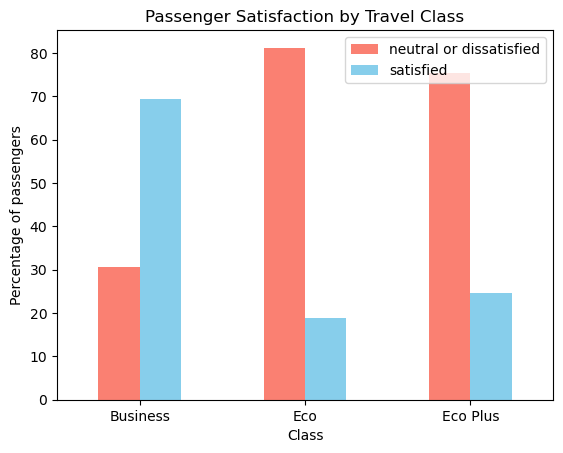

In [32]:
pd.crosstab(merged_df['Class'],merged_df['satisfaction'],normalize='index').mul(100).plot(kind='bar', color=["salmon","skyblue"])
plt.ylabel('Percentage of passengers')
plt.xlabel('Class')
plt.title('Passenger Satisfaction by Travel Class')
plt.legend()
plt.xticks(rotation=0)

#### 3.3.2 by Gender

Text(0, 0.5, '')

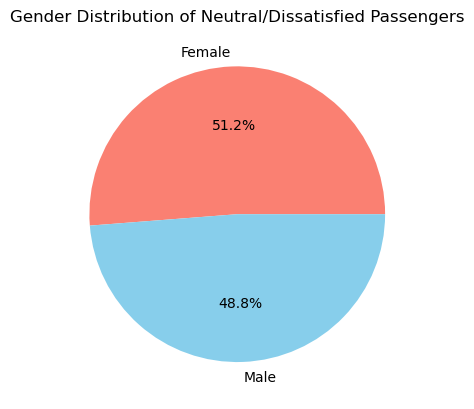

In [34]:
merged_df[merged_df['satisfaction'] == 'neutral or dissatisfied']['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=["salmon","skyblue"])
plt.title('Gender Distribution of Neutral/Dissatisfied Passengers')
plt.ylabel('')

#### 3.3.3 By Age groups

Text(0.5, 1.0, 'Age Distribution of Neutral/Dissatisfied Passengers')

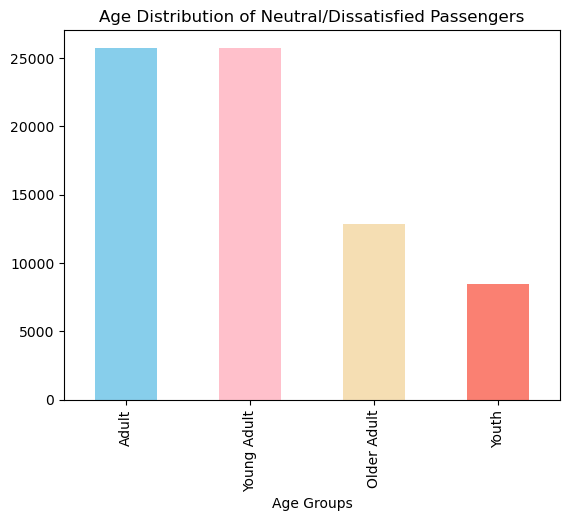

In [38]:
merged_df[merged_df['satisfaction'] == 'neutral or dissatisfied']["Age Groups"].value_counts().plot(kind='bar',color=['skyblue', 'pink', 'wheat','salmon'])
plt.title('Age Distribution of Neutral/Dissatisfied Passengers') # mariam said do bar chart here!

In [672]:
dissatisfied_age = (merged_df[merged_df['satisfaction'] == 'neutral or dissatisfied']['Age Groups'].value_counts(normalize=True).sort_index()* 100)
print(dissatisfied_age)

Age Groups
Youth          11.670694
Young Adult    35.351219
Adult          35.358084
Older Adult    17.620002
Name: proportion, dtype: float64


### 3.4- Correlation between service ratings and passenger satisfaction

In [40]:
# convert satisfaction to 0 and 1
merged_df['satisfaction_numeric'] = merged_df['satisfaction'].map({'neutral or dissatisfied': 0,'satisfied': 1})

In [42]:
services = ['Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking','Gate location','Food and drink','Online boarding','Seat comfort','Inflight entertainment','On-board service','Leg room service','Baggage handling','Checkin service','Inflight service','Cleanliness']

In [44]:
correlation = merged_df[services + ['satisfaction_numeric']].corr()

correlation['satisfaction_numeric'].sort_values(ascending=False)

satisfaction_numeric                 1.000000
Online boarding                      0.501749
Inflight entertainment               0.398234
Seat comfort                         0.348829
On-board service                     0.322205
Leg room service                     0.312424
Cleanliness                          0.307035
Inflight wifi service                0.283460
Baggage handling                     0.248680
Inflight service                     0.244918
Checkin service                      0.237252
Food and drink                       0.211340
Ease of Online booking               0.168877
Gate location                       -0.002793
Departure/Arrival time convenient   -0.054270
Name: satisfaction_numeric, dtype: float64

<Axes: >

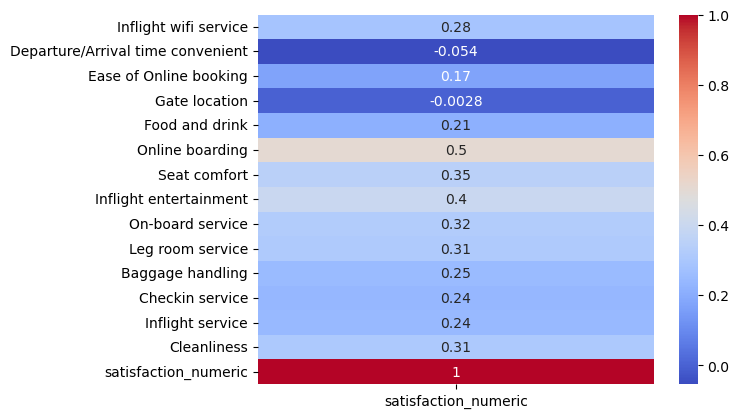

In [50]:
sns.heatmap(correlation[['satisfaction_numeric']],annot=True, cmap="coolwarm")

### 3.5- Why are they dissatisfied?

In [ ]:
dissatisfied = merged_df[merged_df['satisfaction'] == 'neutral or dissatisfied']
dissatisfied_services = (dissatisfied.groupby('Age Groups', observed=True)[services].mean())
dissatisfied_services = dissatisfied_services.loc[['Young Adult', 'Adult']]

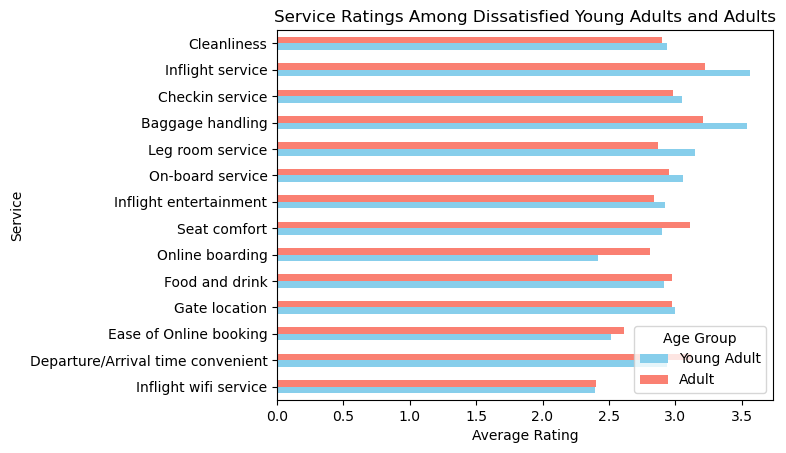

In [65]:
dissatisfied_services.T.plot(kind='barh',color=['skyblue', 'salmon'])
plt.title('Service Ratings Among Dissatisfied Young Adults and Adults')
plt.xlabel('Average Rating')
plt.ylabel('Service')
plt.legend(title='Age Group')

### 3.6- Delay

In [67]:
#creating the delay variable by averaging arrival and departure delay
merged_df["Overall Delay"]= (merged_df["Arrival Delay in Minutes"]+merged_df["Departure Delay in Minutes"])/2

In [71]:
bins = [-1, 0, 15, 30, 60, float('inf')]
labels = ['No delay', '1-15 mins', '16-30 mins', '31-60 mins', '60+ mins']
merged_df['Delay Group'] = pd.cut(merged_df['Overall Delay'],bins=bins,labels=labels)

In [73]:
pd.crosstab(merged_df['Delay Group'],merged_df['satisfaction'],normalize='index') * 100

satisfaction,neutral or dissatisfied,satisfied
Delay Group,,
No delay,52.812926,47.187074
1-15 mins,56.791665,43.208335
16-30 mins,63.859584,36.140416
31-60 mins,63.842697,36.157303
60+ mins,64.276857,35.723143


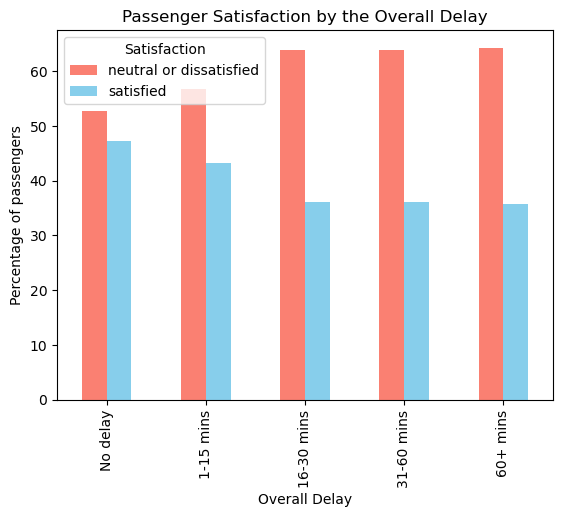

In [75]:
pd.crosstab(merged_df['Delay Group'],merged_df['satisfaction'],normalize='index').mul(100).plot(kind='bar', color=["salmon","skyblue"])
plt.ylabel('Percentage of passengers')
plt.xlabel('Overall Delay')
plt.title('Passenger Satisfaction by the Overall Delay')
plt.legend(title='Satisfaction')

In [326]:
merged_df.groupby('satisfaction')['Overall Delay'].mean()

satisfaction
neutral or dissatisfied    16.698088
satisfied                  12.484430
Name: Overall Delay, dtype: float64